# 23CSE463 – Quantum Computing
## Worksheet 3: Quantum Communication Protocols: Superdense Coding and Quantum Teleportation Using Qiskit

**Name:** Agneay B Nair  
**Reg. No:** CH.SC.U4CSE24102  
**Ex. No:** 3

**Aim:** To implement the superdense coding and quantum teleportation protocols in Qiskit using a shared Bell pair, and to verify that two classical bits can be sent with one qubit and that the state of a qubit can be transferred with two classical bits.

### Setup

In [1]:
# Common setup for all programs in this worksheet
%matplotlib inline
import qiskit, numpy as np, matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

print("Qiskit version:", qiskit.__version__)
sim = AerSimulator()
_seed = 2024                                      # seeds incremented per run -> reproducible counts
np.set_printoptions(precision=3, suppress=True, linewidth=110)
plt.rcParams["figure.dpi"] = 100

def show(fig):
    """display a matplotlib figure (circuit diagram / histogram) and close it"""
    display(fig); plt.close(fig)

def run(qc, shots=1024):
    global _seed
    _seed += 1
    return sim.run(transpile(qc, sim), shots=shots, seed_simulator=_seed).result().get_counts()

def amps(sv, tol=1e-9):
    """print the non-zero amplitudes of a statevector with Qiskit labels (qubit 0 rightmost)"""
    n = sv.num_qubits
    for i, a in enumerate(sv.data):
        if abs(a) > tol:
            print(f"  |{i:0{n}b}> : {a.real:+.3f}{a.imag:+.3f}j   P = {abs(a)**2:.3f}")


from qiskit import QuantumRegister, ClassicalRegister
from qiskit.quantum_info import partial_trace, DensityMatrix


Qiskit version: 2.5.2


### Program 1
Prepare a Bell pair shared between Alice and Bob. Display the statevector and the histogram for 1024 shots.

Bell pair statevector  (label = Bob Alice):
  |00> : +0.707+0.000j   P = 0.500
  |11> : +0.707+0.000j   P = 0.500


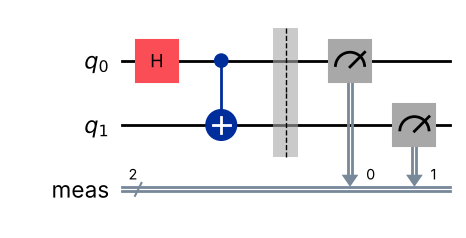

Counts: {'00': 510, '11': 514}


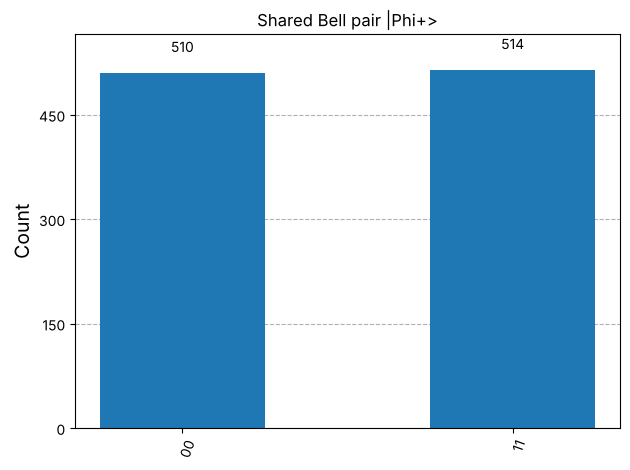

In [2]:
# Program 1: Bell pair shared by Alice (q0) and Bob (q1)
qc = QuantumCircuit(2)
qc.h(0); qc.cx(0, 1)
print("Bell pair statevector  (label = Bob Alice):")
amps(Statevector(qc))
qc.measure_all()
show(qc.draw("mpl"))
counts = run(qc)
print("Counts:", counts)
show(plot_histogram(counts, title="Shared Bell pair |Phi+>"))

**Inference:** The pair is (|00>+|11>)/√2: only 00 and 11 are observed, each ≈50%. Alice's and Bob's results always agree, although each one on its own is random.

### Program 2
Implement superdense coding for the message 00. Draw the complete circuit with barriers between the preparation, encoding and decoding stages, and show the measurement result.

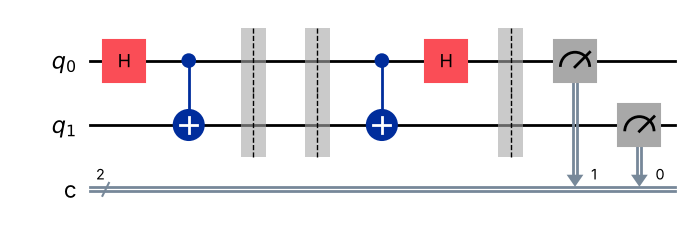

Counts: {'00': 1024}


In [3]:
# Program 2: superdense coding for message 00. Alice = q0, Bob = q1
qc = QuantumCircuit(2, 2)
qc.h(0); qc.cx(0, 1)                 # preparation (shared Bell pair)
qc.barrier()
# encoding for "00": identity (no gate)
qc.barrier()
qc.cx(0, 1); qc.h(0)                 # Bob's decoding
qc.barrier()
qc.measure(0, 1)                     # Alice's qubit -> bit b1 (left)
qc.measure(1, 0)                     # Bob's qubit   -> bit b0 (right)
show(qc.draw("mpl"))
counts = run(qc)
print("Counts:", counts)

**Inference:** Bob reads 00 in all 1024 shots. With no encoding gate the decoding (CNOT then H) simply undoes the Bell-pair preparation, returning |00>. The measurement is wired so that the printed string reads b1b0.

### Program 3
Write a function that builds the superdense coding circuit for any two-bit message. Run it for 00, 01, 10 and 11 and tabulate the message sent against the message received.

Message sent | Alice's gate | Received (counts)
     00      |     I        | {'00': 1024}   OK


     01      |     X        | {'01': 1024}   OK
     10      |     Z        | {'10': 1024}   OK


     11      |     ZX       | {'11': 1024}   OK


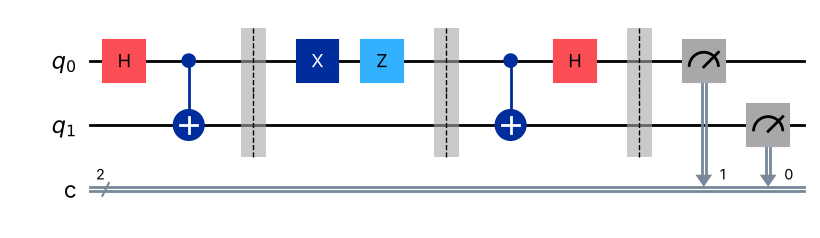

In [4]:
# Program 3: superdense coding for any 2-bit message b1b0
def superdense(msg):
    b1, b0 = msg[0], msg[1]
    qc = QuantumCircuit(2, 2)
    qc.h(0); qc.cx(0, 1); qc.barrier()
    if b0 == "1": qc.x(0)            # X if b0 = 1
    if b1 == "1": qc.z(0)            # then Z if b1 = 1
    qc.barrier()
    qc.cx(0, 1); qc.h(0); qc.barrier()
    qc.measure(0, 1); qc.measure(1, 0)
    return qc

print("Message sent | Alice's gate | Received (counts)")
gate = {"00": "I", "01": "X", "10": "Z", "11": "ZX"}
for m in ["00", "01", "10", "11"]:
    c = run(superdense(m))
    print(f"     {m}      |     {gate[m]:<3}      | {c}   {'OK' if list(c) == [m] else 'ERR'}")
show(superdense("11").draw("mpl"))

**Inference:** Every message 00, 01, 10, 11 is received correctly with 100% probability. Alice's four operations I, X, Z, ZX produce the four orthogonal Bell states, which Bob's Bell measurement distinguishes perfectly: two classical bits are carried by one transmitted qubit.

### Program 4
For each of the four messages, measure only the qubit that Alice sends, without Bob\'s decoding. Show that the result is 0 or 1 with equal probability in every case, and explain what this means for an eavesdropper.

In [5]:
# Program 4: eavesdropper measures only the travelling qubit (Alice's q0), no decoding
print("Message | counts of Alice's qubit alone | P(0)")
for m in ["00", "01", "10", "11"]:
    qc = QuantumCircuit(2, 1)
    qc.h(0); qc.cx(0, 1); qc.barrier()
    if m[1] == "1": qc.x(0)
    if m[0] == "1": qc.z(0)
    qc.barrier()
    qc.measure(0, 0)
    c = run(qc)
    rho = partial_trace(Statevector(qc.remove_final_measurements(inplace=False)), [1])
    print(f"  {m}    | {str(c):<29} | {c.get('0', 0)/1024:.3f}   reduced state =",
          np.round(rho.data.real, 2).tolist())

Message | counts of Alice's qubit alone | P(0)


  00    | {'0': 508, '1': 516}          | 0.496   reduced state = [[0.5, 0.0], [0.0, 0.5]]


  01    | {'0': 492, '1': 532}          | 0.480   reduced state = [[0.5, 0.0], [0.0, 0.5]]


  10    | {'1': 522, '0': 502}          | 0.490   reduced state = [[0.5, 0.0], [0.0, 0.5]]


  11    | {'0': 501, '1': 523}          | 0.489   reduced state = [[0.5, 0.0], [0.0, 0.5]]


**Inference:** For every message the intercepted qubit gives 0 or 1 with ≈50% probability; its reduced density matrix is I/2 in all four cases. An eavesdropper who holds only the travelling qubit learns nothing about the message — the information is stored in the correlation with Bob's qubit.

### Program 5
Implement quantum teleportation of the state $|1\rangle$ using three qubits and classically controlled corrections. Measure Bob\'s qubit and show that it is always 1.

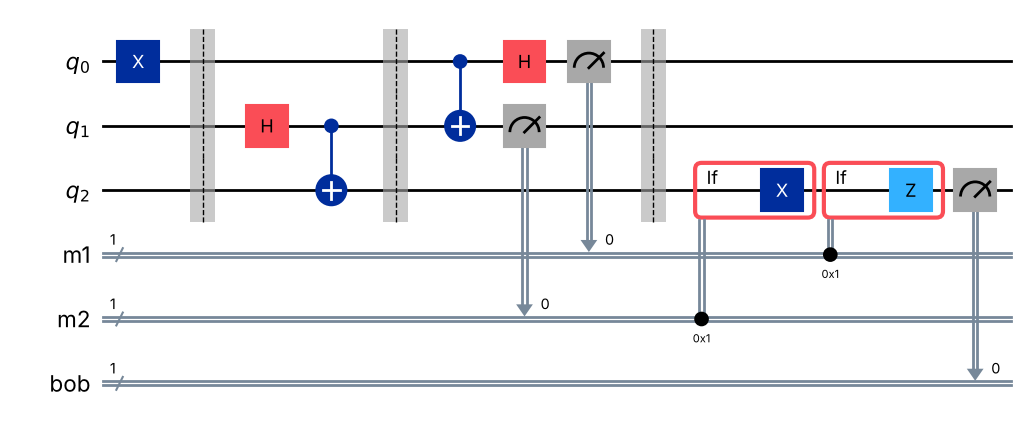

Full counts (bob m2 m1): {'1 0 1': 245, '1 0 0': 273, '1 1 0': 246, '1 1 1': 260}
Bob's qubit: {'1': 1024}


In [6]:
# Program 5: teleport |1>.  q0 = state to send, q1 = Alice's half, q2 = Bob's half
def teleport(prep, bob_basis_h=False, corrections=True):
    q = QuantumRegister(3, "q")
    m1 = ClassicalRegister(1, "m1")          # measurement of q0
    m2 = ClassicalRegister(1, "m2")          # measurement of q1
    b = ClassicalRegister(1, "bob")
    qc = QuantumCircuit(q, m1, m2, b)
    prep(qc)                                 # prepare |psi> on q0
    qc.barrier()
    qc.h(1); qc.cx(1, 2)                     # Bell pair Alice-Bob
    qc.barrier()
    qc.cx(0, 1); qc.h(0)                     # Alice's operations
    qc.measure(0, m1); qc.measure(1, m2)
    qc.barrier()
    if corrections:
        with qc.if_test((m2, 1)):
            qc.x(2)
        with qc.if_test((m1, 1)):
            qc.z(2)
    if bob_basis_h:
        qc.h(2)
    qc.measure(2, b)
    return qc

def bob_counts(counts):
    out = {}
    for k, v in counts.items():
        bit = k.split()[0]                   # key = "bob m2 m1"
        out[bit] = out.get(bit, 0) + v
    return out

qc = teleport(lambda c: c.x(0))
show(qc.draw("mpl"))
counts = run(qc)
print("Full counts (bob m2 m1):", counts)
print("Bob's qubit:", bob_counts(counts))

**Inference:** Alice's two bits are random (all four combinations ≈25%), but after the classically controlled X/Z corrections Bob's qubit measures 1 in all 1024 shots: the state |1> has been teleported.

### Program 6
Teleport the state $| + \rangle$. Apply a Hadamard gate to Bob\'s qubit before measuring it and show that the result is always 0.

Bob's qubit after H: {'0': 1024}


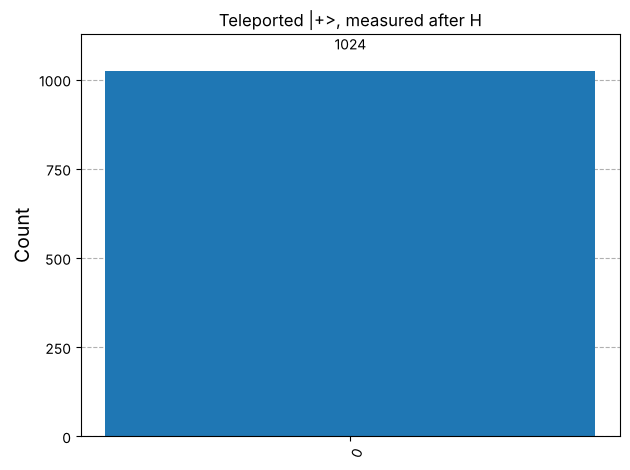

In [7]:
# Program 6: teleport |+>; Bob applies H before measuring
qc = teleport(lambda c: c.h(0), bob_basis_h=True)
counts = run(qc)
print("Bob's qubit after H:", bob_counts(counts))
show(plot_histogram(bob_counts(counts), title="Teleported |+>, measured after H"))

**Inference:** Bob always measures 0 after the H gate, so his qubit was exactly |+> (H|+> = |0>). This shows that the superposition including its relative phase is transferred, not just a classical bit.

### Program 7
Teleport the state $R_{y}(\theta)|0\rangle$ with $\theta = \pi/3$. Show that Bob\'s qubit measures 1 with probability $\sin^{2}(\theta/2) = 0.25$, using at least 8192 shots.

Bob's counts: {'1': 2023, '0': 6169}
Measured P(1) = 0.2469   expected sin^2(theta/2) = 0.2500


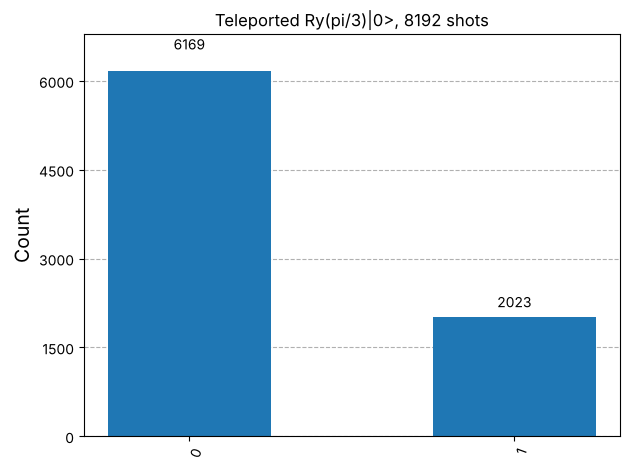

In [8]:
# Program 7: teleport Ry(pi/3)|0>, 8192 shots
theta = np.pi / 3
qc = teleport(lambda c: c.ry(theta, 0))
counts = bob_counts(run(qc, shots=8192))
p1 = counts.get("1", 0) / 8192
print("Bob's counts:", counts)
print(f"Measured P(1) = {p1:.4f}   expected sin^2(theta/2) = {np.sin(theta/2)**2:.4f}")
show(plot_histogram(counts, title="Teleported Ry(pi/3)|0>, 8192 shots"))

**Inference:** Bob's qubit measures 1 with probability close to the expected sin²(π/6) = 0.25 (the small difference is shot noise, ≈ ±0.005 for 8192 shots), confirming that an arbitrary amplitude is teleported faithfully.

### Program 8
Repeat Program 7 with Bob\'s corrections removed. Show that Bob\'s qubit now measures 0 and 1 with equal probability, and explain why the classical bits are necessary.

Bob's counts without corrections: {'1': 4099, '0': 4093}
P(1) = 0.5004


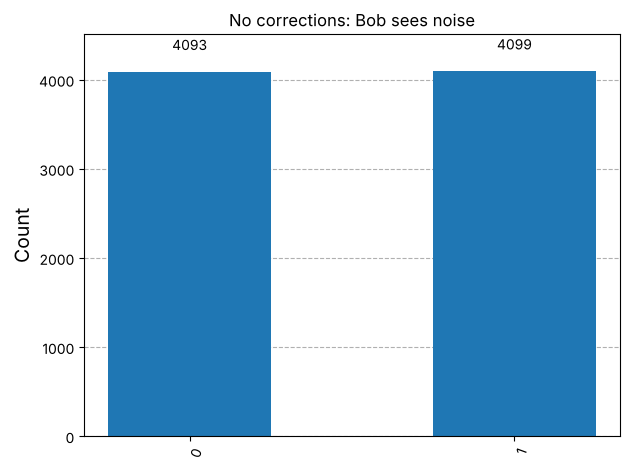

In [9]:
# Program 8: same as Program 7 but WITHOUT Bob's corrections
qc = teleport(lambda c: c.ry(theta, 0), corrections=False)
counts = bob_counts(run(qc, shots=8192))
print("Bob's counts without corrections:", counts)
print(f"P(1) = {counts.get('1', 0)/8192:.4f}")
show(plot_histogram(counts, title="No corrections: Bob sees noise"))

**Inference:** Without the corrections Bob gets 0 and 1 with ≈50% each: averaged over Alice's four random outcomes his qubit is in the maximally mixed state I/2. Only the two classical bits tell Bob which of X, Z, ZX or I to apply, so they are necessary — and since they travel no faster than light, teleportation cannot be used for faster-than-light signalling.

### Program 9
Replace the classically controlled corrections with a CNOT gate and a CZ gate controlled by Alice\'s qubits (deferred measurement). Show that Bob\'s result is the same as in Program 7.

Bob's reduced density matrix:
 [[0.75  0.433]
 [0.433 0.25 ]]
Equal to |psi><psi| : True


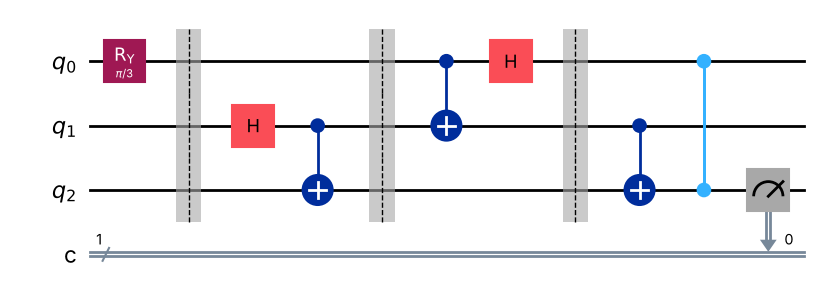

Bob's counts: {'1': 1972, '0': 6220}   P(1) = 0.2407


In [10]:
# Program 9: deferred measurement - quantum-controlled corrections
qc = QuantumCircuit(3, 1)
qc.ry(theta, 0); qc.barrier()
qc.h(1); qc.cx(1, 2); qc.barrier()
qc.cx(0, 1); qc.h(0); qc.barrier()
qc.cx(1, 2)                       # replaces "X if m2 = 1"
qc.cz(0, 2)                       # replaces "Z if m1 = 1"
# exact check: Bob's reduced state equals Ry(theta)|0>
rho_bob = partial_trace(Statevector(qc), [0, 1])
psi = QuantumCircuit(1); psi.ry(theta, 0)
target = DensityMatrix(Statevector(psi))
print("Bob's reduced density matrix:\n", np.round(rho_bob.data.real, 3))
print("Equal to |psi><psi| :", np.allclose(rho_bob.data, target.data))
qc.measure(2, 0)
show(qc.draw("mpl"))
counts = run(qc, shots=8192)
print("Bob's counts:", counts, f"  P(1) = {counts.get('1', 0)/8192:.4f}")

**Inference:** With CNOT and CZ controlled by Alice's qubits the result is the same as Program 7: P(1) ≈ 0.25 and Bob's reduced density matrix equals |ψ><ψ| exactly. By the principle of deferred measurement, classically controlled gates after a measurement are equivalent to quantum-controlled gates before it.

## Viva Q&A

**1. What is a Bell pair, and how is it prepared?**  
A Bell pair is a maximally entangled two-qubit state such as |Φ+> = (|00>+|11>)/√2. It is prepared from |00> with a Hadamard on the first qubit followed by a CNOT from the first to the second.

**2. How many classical bits does one qubit carry in superdense coding, and what must be shared in advance?**  
One transmitted qubit carries two classical bits, but only if Alice and Bob share one entangled Bell pair in advance (Alice holds one half, Bob the other).

**3. Which gate does Alice apply for each of the four messages 00, 01, 10 and 11?**  
00 → I (no gate), 01 → X, 10 → Z, 11 → ZX (X followed by Z, equivalent to iY up to phase).

**4. How does Bob decode the message in superdense coding?**  
Bob performs a Bell-basis measurement: a CNOT with Alice's qubit as control and his own as target, then a Hadamard on Alice's qubit, then measures both qubits to read b1b0.

**5. What is transferred in quantum teleportation: the qubit itself or its state?**  
Only the quantum state (the amplitudes α, β) is transferred; no particle or matter travels from Alice to Bob. Bob's own qubit takes on the state.

**6. Why are two classical bits needed for teleportation?**  
Alice's measurement has four equally likely outcomes, each leaving Bob's qubit in a different version of |ψ> (I, X, Z or ZX applied). Two bits are needed to tell Bob which of the four corrections to apply.

**7. Why does teleportation not violate the no-cloning theorem?**  
Alice's measurement destroys the original state on her qubit, so at the end only Bob has |ψ>. At no time do two copies exist, so the no-cloning theorem is respected.

**8. Why does teleportation not allow communication faster than light?**  
Before the two classical bits arrive, Bob's qubit is in the maximally mixed state I/2 whatever |ψ> is, so he learns nothing. The classical bits travel at most at the speed of light, so no information arrives faster than light.

**9. Which correction does Bob apply for each of Alice\'s four measurement results?**  
m1m2 = 00 → I, 01 → X, 10 → Z, 11 → ZX (X first, then Z), where m1 is the measurement of the state qubit and m2 that of Alice's half of the pair.

**10. How are superdense coding and teleportation related to each other?**  
They are mirror images (dual protocols): superdense coding uses 1 Bell pair + 1 qubit sent to carry 2 classical bits, while teleportation uses 1 Bell pair + 2 classical bits sent to carry 1 qubit. Both rely on the four Bell states being perfectly distinguishable.

## Result

Superdense coding and quantum teleportation were implemented in Qiskit using a shared Bell pair. All four two-bit messages were transmitted with 100% accuracy using one qubit, and an intercepted qubit alone was shown to give random results. The states |1>, |+> and Ry(π/3)|0> were teleported (P(1) ≈ 0.25 for the last), the necessity of the two classical bits was demonstrated by removing the corrections, and the deferred-measurement version gave the same result. Hence the experiment was successfully completed.